# 유니버스 golden_cross 분석

`list_universe` → `run_universe_backtest` → 종목·기간 공통점.

**효과:** `excess_return > 0` 그리고 `max_drawdown >= mdd_limit` (기본 -30%).

**생존편향:** 기준일 시총으로 고른 뒤 과거부터 돌리면, 그 날짜에 남아 있는 대형주만 남습니다. PIT에 가깝게 보려면 `as_of`를 백테스트 `start`로 맞추세요. `as_of`가 휴일이면 그 이전 마지막 거래일을 씁니다.

업종은 `security_master`에 없습니다. 공통점은 시장·시총·실현변동성·buy&hold(추세)·거래횟수로 봅니다.

전체 유니버스(~1,200종목)는 수분 걸릴 수 있습니다. `MAX_NAMES`로 스모크하거나, 저장된 parquet를 로드하세요.

투자 조언을 제공하지 않습니다.

In [10]:
from datetime import date
from pathlib import Path

from backtest import list_universe, load_run_panel, run_universe_backtest, save_run_panel
from backtest.analytics import (
    attach_size_quintile,
    period_hit_rates,
    plot_excess_scatter,
    plot_period_hit_rate,
    stock_axis_summary,
    stock_group_summary,
)

as_of = date(2020, 1, 2)
min_market_cap = 100_000_000_000  # 1,000억 원
start = date(2020, 1, 2)
end = None
fast = 50
slow = 120
initial_cash = 10_000_000.0
fee_rate = 0.0015
mdd_limit = -0.30
MAX_NAMES = 40  # 전체는 None
RUN_DIR = Path("backtest_runs") / f"golden_cross_cap1000eok_{as_of.isoformat()}"
RELOAD = RUN_DIR.exists() and MAX_NAMES is None

In [11]:
universe = list_universe(
    as_of=as_of,
    min_market_cap=min_market_cap,
)
print(f"universe n={len(universe)}")
if universe.empty:
    print("empty universe — as_of 이전에 일봉이 없습니다")
else:
    print(f"session as_of={universe['as_of'].dt.date.iloc[0]}")
universe.head()

universe n=1055
session as_of=2020-01-02


,security_id,name,market,market_cap,as_of
0,KRX:005930,삼성전자,KOSPI,3.295320e+14,2020-01-02
1,KRX:000660,SK하이닉스,KOSPI,6.894182e+13,2020-01-02
2,KRX:005935,삼성전자우,KOSPI,3.752363e+13,2020-01-02
3,KRX:035420,NAVER,KOSPI,3.007844e+13,2020-01-02
4,KRX:207940,삼성바이오로직스,KOSPI,2.835170e+13,2020-01-02


In [12]:
if RELOAD:
    panel = load_run_panel(RUN_DIR)
    print(f"loaded {RUN_DIR}")
else:
    names = universe if MAX_NAMES is None else universe.head(MAX_NAMES)
    panel = run_universe_backtest(
        "golden_cross",
        names,
        start=start,
        end=end,
        initial_cash=initial_cash,
        fee_rate=fee_rate,
        mdd_limit=mdd_limit,
        fast=fast,
        slow=slow,
    )
    if MAX_NAMES is None:
        save_run_panel(panel, RUN_DIR)
        print(f"saved {RUN_DIR}")

summaries = attach_size_quintile(panel.summaries)
ok = summaries[summaries["error"].fillna("") == ""]
print(f"ok={len(ok)}  effective={int(ok['effective'].sum())}  errors={int((summaries['error'].fillna('') != '').sum())}")
ok.sort_values("excess_return", ascending=False).head(10)

ok=40  effective=0  errors=0


,security_id,name,market,market_cap,total_return,buy_hold_return,excess_return,max_drawdown,buy_hold_mdd,cagr,realized_vol,trade_count,bars,effective,error,size_quintile
27,KRX:066570,LG전자,KOSPI,1.161899e+13,3.838810,1.559155,2.279655,-0.622930,-0.650270,0.277567,0.030404,11,1622,False,,Q2
2,KRX:005935,삼성전자우,KOSPI,3.752363e+13,4.606371,2.951754,1.654617,-0.357447,-0.483951,0.307128,0.022397,11,1622,False,,Q5
14,KRX:017670,SK텔레콤,KOSPI,1.889450e+13,0.526373,-0.632479,1.158852,-0.375399,-0.869611,0.068963,0.045936,13,1598,False,,Q4
0,KRX:005930,삼성전자,KOSPI,3.295320e+14,4.449685,3.338768,1.110916,-0.428966,-0.451648,0.301384,0.023794,9,1622,False,,Q5
9,KRX:005490,POSCO홀딩스,KOSPI,2.057609e+13,1.093888,0.383475,0.710413,-0.451377,-0.649696,0.121669,0.026135,10,1622,False,,Q4
36,KRX:011170,롯데케미칼,KOSPI,7.489179e+12,-0.027962,-0.734096,0.706134,-0.490596,-0.837195,-0.004397,0.031289,10,1622,False,,Q1
32,KRX:009540,HD한국조선해양,KOSPI,8.882026e+12,2.691627,2.171315,0.520312,-0.352528,-0.568224,0.224969,0.028141,12,1622,False,,Q1
22,KRX:035720,카카오,KOSPI,1.314759e+13,-0.228645,-0.733115,0.504470,-0.412255,-0.941219,-0.039603,0.046299,12,1619,False,,Q3
21,KRX:096770,SK이노베이션,KOSPI,1.354621e+13,0.327044,-0.152901,0.479945,-0.515806,-0.744567,0.044941,0.033449,10,1622,False,,Q3
5,KRX:005380,현대차,KOSPI,2.521285e+13,2.803623,2.415254,0.388368,-0.532000,-0.532000,0.230670,0.026122,12,1622,False,,Q5


## 종목: 효과적 vs 비효과적

그룹 중앙값과 시장·시총 분위 분포. 상위/하위 excess 종목을 비교하세요.

In [13]:
display(stock_group_summary(summaries))
display(stock_axis_summary(summaries, by="market"))
display(stock_axis_summary(summaries, by="size_quintile"))
print("least excess")
display(ok.sort_values("excess_return").head(10))

,effective,n,excess_median,mdd_median,market_cap_median,trade_count_median,realized_vol_median,buy_hold_median
0,False,40,-0.051622,-0.458866,1.473827e+13,13.0,0.026157,0.979066


,market,effective,n,excess_median
0,KOSPI,False,40,-0.051622


/Users/jaeyulim/my-project/trading-workspace/trading-labs/src/backtest/analytics/cross_section.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frame.groupby([by, "effective"], dropna=False)


,size_quintile,effective,n,excess_median
0,Q1,False,8,0.005781
1,Q2,False,8,-0.341671
2,Q3,False,8,-0.074048
3,Q4,False,8,0.194243
4,Q5,False,8,-0.172447


least excess


,security_id,name,market,market_cap,total_return,buy_hold_return,excess_return,max_drawdown,buy_hold_mdd,cagr,realized_vol,trade_count,bars,effective,error,size_quintile
1,KRX:000660,SK하이닉스,KOSPI,6.894182e+13,8.741295,14.047518,-5.306224,-0.547105,-0.547105,0.424279,0.032154,11,1622,False,,Q5
31,KRX:009150,삼성전기,KOSPI,9.448753e+12,5.676291,8.976285,-3.299994,-0.612775,-0.612775,0.343083,0.030761,19,1622,False,,Q2
4,KRX:207940,삼성바이오로직스,KOSPI,2.835170e+13,-0.018885,2.754959,-2.773844,-0.349787,-0.367430,-0.002989,0.023463,18,1605,False,,Q5
20,KRX:032830,삼성생명,KOSPI,1.462000e+13,1.477902,2.960328,-1.482426,-0.468813,-0.567751,0.151400,0.026528,13,1622,False,,Q3
28,KRX:000810,삼성화재,KOSPI,1.129890e+13,0.324604,1.687631,-1.363027,-0.358842,-0.471698,0.044643,0.025067,19,1622,False,,Q2
10,KRX:028260,삼성물산,KOSPI,2.039168e+13,1.323258,2.204651,-0.881394,-0.466355,-0.466355,0.139930,0.026218,15,1622,False,,Q4
34,KRX:010130,고려아연,KOSPI,8.000880e+12,1.100102,1.898585,-0.798483,-0.663581,-0.673500,0.122185,0.034294,14,1622,False,,Q1
33,KRX:316140,우리금융지주,KOSPI,8.233852e+12,1.196981,1.964912,-0.767931,-0.368279,-0.424561,0.130075,0.019552,14,1622,False,,Q1
29,KRX:086790,하나금융지주,KOSPI,1.079370e+13,1.805205,2.552156,-0.746951,-0.403208,-0.490331,0.173809,0.023188,13,1622,False,,Q2
23,KRX:033780,KT&G,KOSPI,1.269956e+13,0.222762,0.944865,-0.722103,-0.262089,-0.331230,0.031739,0.015111,15,1622,False,,Q3


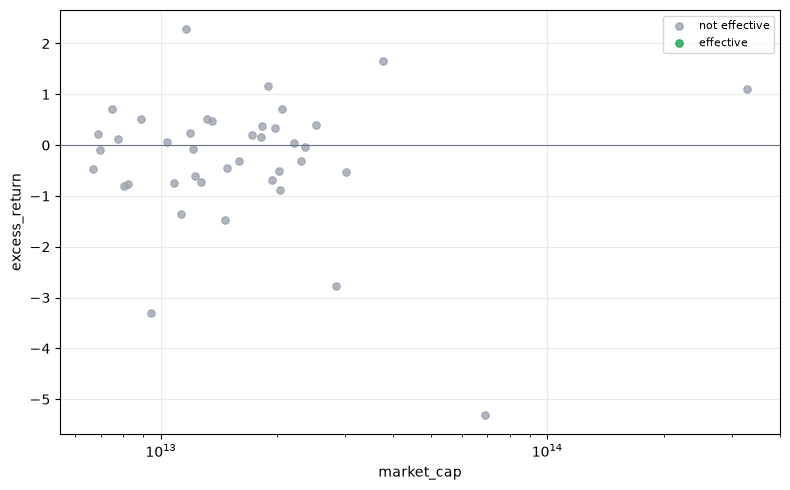

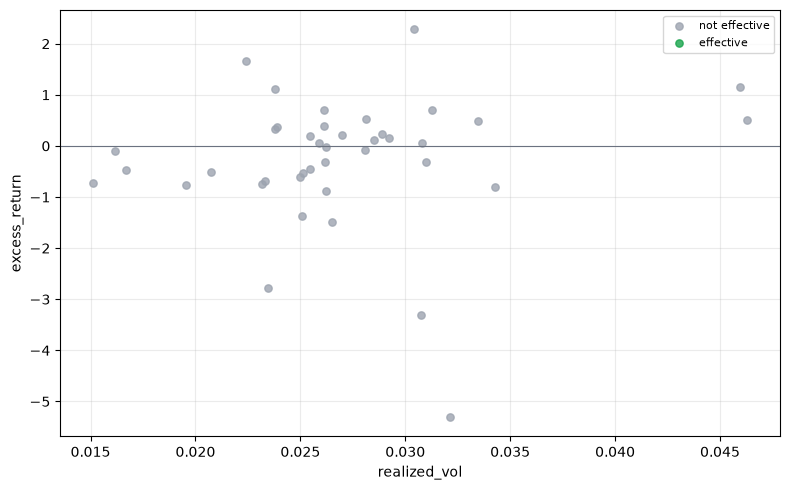

In [14]:
plot_excess_scatter(summaries, x="market_cap", show=True)
plot_excess_scatter(summaries, x="realized_vol", show=True)

## 기간: 언제 효과가 있었나

연도별 hit rate(`excess>0` 비율)와 그해 유니버스 buy&hold 중앙값. 장세가 강한 해와 hit rate가 같이 움직이는지 봅니다.

,period,freq,n,hit_rate,excess_median,universe_bh_median
0,2020,YE,40,0.600,0.080205,0.191602
1,2021,YE,40,0.575,0.037247,-0.032964
2,2022,YE,40,0.675,0.097539,-0.179483
3,2023,YE,40,0.300,-0.092544,0.097742
4,2024,YE,40,0.525,0.027095,-0.118928
5,2025,YE,40,0.125,-0.188604,0.387770
6,2026,YE,40,0.275,0.000000,0.261791


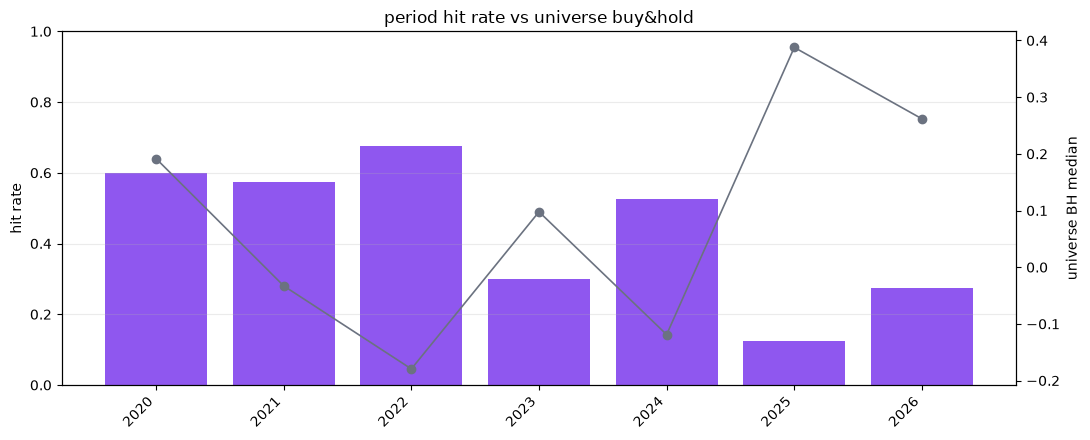

In [15]:
yearly = period_hit_rates(panel.period_returns, freq="YE")
display(yearly)
plot_period_hit_rate(yearly, show=True)

In [16]:
monthly = period_hit_rates(panel.period_returns, freq="ME")
monthly.tail(24)

,period,freq,n,hit_rate,excess_median,universe_bh_median
56,2024-09,ME,40,0.250,0.000000e+00,0.007942
57,2024-10,ME,40,0.525,1.665335e-16,-0.014066
58,2024-11,ME,40,0.650,2.220446e-16,-0.012942
59,2024-12,ME,40,0.500,5.551115e-17,-0.048845
60,2025-01,ME,40,0.250,0.000000e+00,0.039698
61,2025-02,ME,40,0.325,-5.551115e-17,0.004131
62,2025-03,ME,40,0.475,0.000000e+00,-0.017000
63,2025-04,ME,40,0.400,0.000000e+00,0.022669
64,2025-05,ME,40,0.300,-3.071781e-03,0.035599
65,2025-06,ME,40,0.075,-5.602251e-02,0.116811
